# Model Comparison from `theis.py`

This notebook compares three models for the **wellbore injection pressure** $p_w(t)$:
- `pressure_injection_theis` (Theis, transient)
- `radial_composite_pressure` (Benson & Bodvarsson 1986, two-viscosity zones)
- `thiem_doublet_pressure` (potential theory, steady-state, S = 0)

using the parameter set from `sensitivity2.ipynb`.

Storativity:
- consistent coupling: $S = \rho_F g M \phi c_t$

Viscosities:
- $\mu_1$ (water at 10 degC): 1.307e-3 Pa s
- $\mu_2$ (water at 80 degC): 3.55e-4 Pa s

Doublet spacing: $2a = 900$ m (based on the Charbeneau/Schulz example set)

## Governing formulas (with extraction-well correction)

All formulas give the **injection wellbore pressure** $p_w(t)$ at the injection well
($r = r_w$), including the pressure perturbation of the extraction well via superposition
(doublet correction, $-W(u_{extr})$ or $-\mu_2 W(\cdot)$ term).

### Theis model with optional doublet correction

$$
p_w(t) = p_{res} + \rho g\left[-\frac{Q}{4\pi T}\big(W(u_w)-W(u_{extr})\big)\right]
$$

with

$$
u_w = \frac{r_w^2 S}{4Tt},\quad u_{extr}=\frac{(2a)^2S}{4Tt}
$$

and $W(u)=-\mathrm{Ei}(-u)$.

### Composite model with optional doublet correction

$$
p_w(t)=p_0+\frac{Q}{4\pi Mk}\left[\mu_2 W\!\left(\frac{r_w^2}{4\eta_2 t}\right)+(\mu_1-\mu_2)\ln\!\left(\frac{r_f(t)}{r_w}\right)-\mu_2 W\!\left(\frac{(2a)^2}{4\eta_2 t}\right)\right]
$$

with

$$
\eta_2=\frac{k}{\phi\mu_2 c_t},\quad r_f(t)=\sqrt{\frac{Qt}{\pi M\phi R}}
$$

### Thiem steady-state doublet solution

$$
p_w = p_{res} + \frac{Q\mu}{2\pi kM}\ln\!\left(\frac{2a}{r_w}\right)
$$

Reason for $2a$: it is the center-to-center spacing between injection and extraction wells.
In potential-theory superposition, source and sink terms are evaluated at $r_w$ and $2a$,
so the far-field radius cancels and the ratio $2a/r_w$ remains.

## Interpretation: composite curves between Theis bounds

The pure Theis curves with $\mu_1$ (cold) and $\mu_2$ (warm) are **limiting cases** in which
the entire aquifer has a single, uniform viscosity. They form the upper and lower bounds on
injection pressure.

The composite model always has **two zones simultaneously**:

- **cold→warm**: Cold injected water near the wellbore (Zone 2, high viscosity → elevated
  pressure), warm reservoir further out (Zone 1, low viscosity → dampens the rise). The
  injection pressure therefore stays *below* the pure Theis($\mu_1$) value.
- **warm→cold**: Warm water near the wellbore (Zone 2, low viscosity → lower pressure
  requirement), cold reservoir further out (Zone 1, high viscosity → raises the pressure).
  The injection pressure therefore stays *above* the pure Theis($\mu_2$) value.

Both composite curves are thus necessarily between the Theis bounds.

## Model validity: thermal breakthrough

The piston-displacement front reaches the extraction well at distance $2a$ at time

$$
t_{bt} = \frac{\pi M \phi R\,(2a)^2}{Q}
$$

Beyond $t_{bt}$, cold injected water arrives at the extraction well (**thermal breakthrough**).
The viscosity distribution in the aquifer then changes fundamentally, and the two-zone
composite model loses its validity. The thermal breakthrough time is indicated as a vertical
line in the plots.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from theis import (
    pressure_injection_theis,
    transmissivity,
    radial_composite_pressure,
    thiem_doublet_pressure,
    )

plt.style.use('seaborn-v0_8-whitegrid')

# Parameters from sensitivity2.ipynb (example set)
M = 30.0
k = 1e-12
Q = -0.03                 # sign convention in pressure_injection_theis: injection < 0
S = 1e-4                  # storativity
rw = 0.1
rho_F = 1000.0
g = 9.81
p_res = 1.0e6

# Water viscosities
mu1 = 1.307e-3            # Pa s, approx. 10 degC
mu2 = 3.55e-4             # Pa s, approx. 80 degC

# Additional parameters for radial_composite_pressure
phi = 0.2
R = 1.5

# Half spacing for Thiem doublet solution (Charbeneau/Schulz example set)
a = 450.0                 # m

# Consistent coupling of S and ct for comparing Theis formulations:
# phi * ct = S / (rho_F * g * M)  ->  ct = S / (phi * rho_F * g * M)
ct = S / (phi * rho_F * g * M)

# Simulation duration
t_max = 40.0              # years

# Time axis (near 0 to t_max, excluding t=0 singularity)
t_years = np.linspace(0.01, t_max, 400)
t_seconds = t_years * 365.0 * 24.0 * 3600.0

print(f'S (set): {S:.3e} [-]')
print(f'ct (derived from S): {ct:.3e} 1/Pa')
print(f'mu1 (10 degC): {mu1:.3e} Pa s, mu2 (80 degC): {mu2:.3e} Pa s')
print(f'Half well spacing a: {a:.0f} m')
print(f'Simulation time: {t_max:.1f} years')


S (set): 1.000e-04 [-]
ct (derived from S): 1.699e-09 1/Pa
mu1 (10 degC): 1.307e-03 Pa s, mu2 (80 degC): 3.550e-04 Pa s
Half well spacing a: 450 m
Simulation time: 40.0 years


In [2]:
# 1) pressure_injection_theis: single-well and doublet variant
T_mu1 = transmissivity(M, k, rho_F, g, mu1)
T_mu2 = transmissivity(M, k, rho_F, g, mu2)

# Single-well (no a_doublet)
p_pi_mu1 = pressure_injection_theis(
    t_array=t_seconds, Q=Q, T=T_mu1, S=S, rw=rw, rho=rho_F, g=g, p_res=p_res
)
p_pi_mu2 = pressure_injection_theis(
    t_array=t_seconds, Q=Q, T=T_mu2, S=S, rw=rw, rho=rho_F, g=g, p_res=p_res
)

# Doublet correction (a_doublet=a)
p_pi_d_mu1 = pressure_injection_theis(
    t_array=t_seconds, Q=Q, T=T_mu1, S=S, rw=rw, rho=rho_F, g=g, p_res=p_res,
    a_doublet=a
)
p_pi_d_mu2 = pressure_injection_theis(
    t_array=t_seconds, Q=Q, T=T_mu2, S=S, rw=rw, rho=rho_F, g=g, p_res=p_res,
    a_doublet=a
)

# 2) radial_composite_pressure: all four cases
Q_rc = abs(Q)

# Case 1: cold into warm
p_rc_ciw = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu1, mu2=mu2, R=R, r_w=rw, p0=p_res
)
p_rc_ciw_d = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu1, mu2=mu2, R=R, r_w=rw, p0=p_res, a_doublet=a
)

# Case 2: warm into cold
p_rc_wic = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu2, mu2=mu1, R=R, r_w=rw, p0=p_res
)
p_rc_wic_d = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu2, mu2=mu1, R=R, r_w=rw, p0=p_res, a_doublet=a
)

# Case 3: no viscosity contrast, cold (mu1=mu2=mu1)
p_rc_cic = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu1, mu2=mu1, R=R, r_w=rw, p0=p_res
)
p_rc_cic_d = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu1, mu2=mu1, R=R, r_w=rw, p0=p_res, a_doublet=a
)

# Case 4: no viscosity contrast, warm (mu1=mu2=mu2)
p_rc_wiw = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu2, mu2=mu2, R=R, r_w=rw, p0=p_res
)
p_rc_wiw_d = radial_composite_pressure(
    t=t_seconds, Q=Q_rc, M=M, k=k, phi=phi, ct=ct,
    mu1=mu2, mu2=mu2, R=R, r_w=rw, p0=p_res, a_doublet=a
)

# 3) Thiem steady-state
p_thiem_mu1 = thiem_doublet_pressure(Q=Q_rc, k=k, M=M, mu=mu1, a=a, r_w=rw, p_res=p_res)
p_thiem_mu2 = thiem_doublet_pressure(Q=Q_rc, k=k, M=M, mu=mu2, a=a, r_w=rw, p_res=p_res)

# Convert to bar
dp_pi_mu1    = (p_pi_mu1    - p_res) / 1e5
dp_pi_mu2    = (p_pi_mu2    - p_res) / 1e5
dp_pi_d_mu1  = (p_pi_d_mu1  - p_res) / 1e5
dp_pi_d_mu2  = (p_pi_d_mu2  - p_res) / 1e5
dp_rc_ciw    = (p_rc_ciw    - p_res) / 1e5
dp_rc_ciw_d  = (p_rc_ciw_d  - p_res) / 1e5
dp_rc_wic    = (p_rc_wic    - p_res) / 1e5
dp_rc_wic_d  = (p_rc_wic_d  - p_res) / 1e5
dp_rc_cic    = (p_rc_cic    - p_res) / 1e5
dp_rc_cic_d  = (p_rc_cic_d  - p_res) / 1e5
dp_rc_wiw    = (p_rc_wiw    - p_res) / 1e5
dp_rc_wiw_d  = (p_rc_wiw_d  - p_res) / 1e5
dp_thiem_mu1 = (p_thiem_mu1 - p_res) / 1e5
dp_thiem_mu2 = (p_thiem_mu2 - p_res) / 1e5

# Thermal breakthrough time (piston front reaches extraction well at r = 2a)
t_bt_seconds = np.pi * M * phi * R * (2 * a)**2 / Q_rc
t_bt_years   = t_bt_seconds / (365.0 * 24.0 * 3600.0)

# Consistency checks
print(f'Theis doublet (mu1) at t=t_max: {dp_pi_d_mu1[-1]:.2f} bar  |  Thiem(mu1): {dp_thiem_mu1:.2f} bar')
print(f'Theis doublet (mu2) at t=t_max: {dp_pi_d_mu2[-1]:.2f} bar  |  Thiem(mu2): {dp_thiem_mu2:.2f} bar')
print(f'Max dev. composite cold/cold vs. Theis(mu1):             {np.max(np.abs(dp_rc_cic   - dp_pi_mu1)):.2e} bar')
print(f'Max dev. composite cold/cold (doublet) vs. Theis doublet: {np.max(np.abs(dp_rc_cic_d - dp_pi_d_mu1)):.2e} bar')
print(f'Thermal breakthrough time: {t_bt_years:.1f} years')


Theis doublet (mu1) at t=t_max: 18.94 bar  |  Thiem(mu1): 18.94 bar
Theis doublet (mu2) at t=t_max: 5.14 bar  |  Thiem(mu2): 5.14 bar
Max dev. composite cold/cold vs. Theis(mu1):             1.07e-14 bar
Max dev. composite cold/cold (doublet) vs. Theis doublet: 1.42e-14 bar
Thermal breakthrough time: 24.2 years


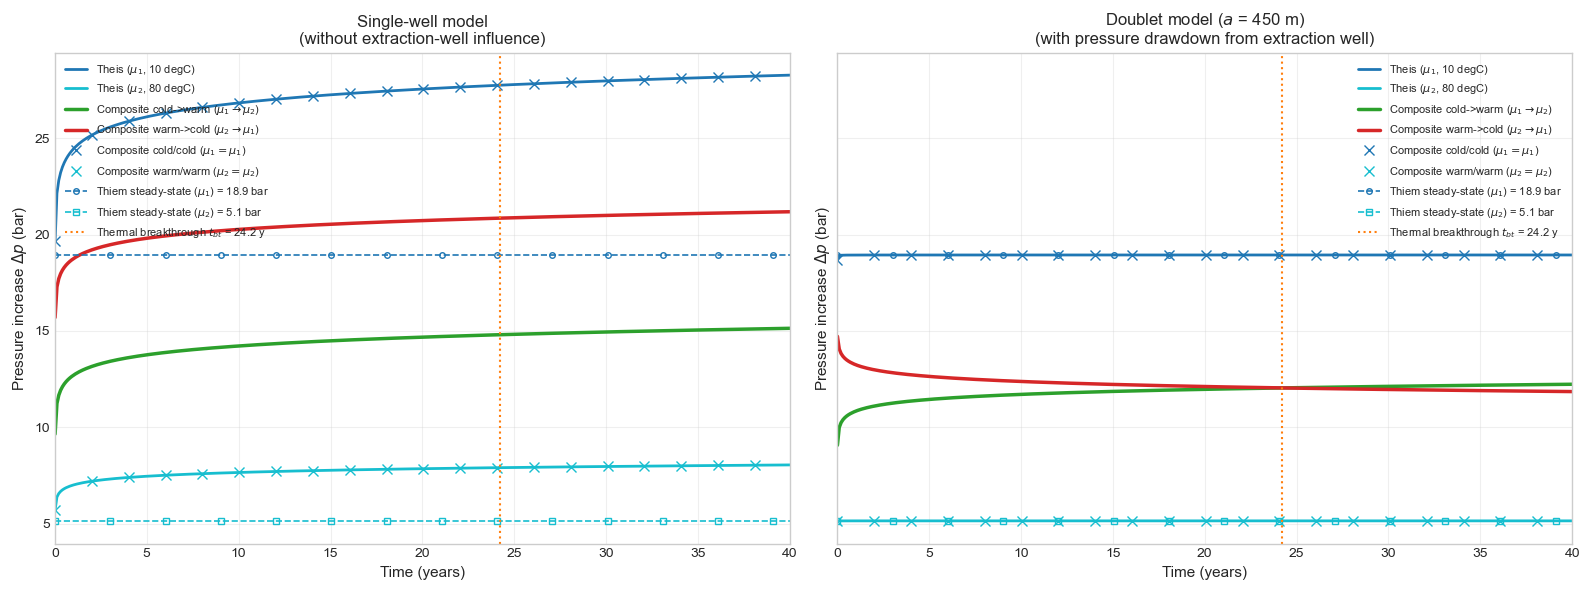

In [3]:
t_markers = t_years[::20]

def draw_panel(ax, pi_mu1, pi_mu2, rc_ciw, rc_wic, rc_cic, rc_wiw,
               thiem_mu1, thiem_mu2, title):
    ax.plot(t_years,   pi_mu1,  color='tab:blue',  linewidth=2.0,
            label='Theis ($\\mu_1$, 10 degC)')
    ax.plot(t_years,   pi_mu2,  color='tab:cyan',  linewidth=2.0,
            label='Theis ($\\mu_2$, 80 degC)')
    ax.plot(t_years,   rc_ciw,  color='tab:green', linewidth=2.5,
            label='Composite cold->warm ($\\mu_1 \\to \\mu_2$)')
    ax.plot(t_years,   rc_wic,  color='tab:red',   linewidth=2.5,
            label='Composite warm->cold ($\\mu_2 \\to \\mu_1$)')
    ax.plot(t_markers, rc_cic[::20], color='tab:blue', marker='x', markersize=7,
            linestyle='none', label='Composite cold/cold ($\\mu_1 = \\mu_1$)')
    ax.plot(t_markers, rc_wiw[::20], color='tab:cyan', marker='x', markersize=7,
            linestyle='none', label='Composite warm/warm ($\\mu_2 = \\mu_2$)')

    # Thiem lines: dashed + marker (clearly distinguishable from 'x')
    ax.plot(t_years, np.full_like(t_years, thiem_mu1),
            color='tab:blue', linewidth=1.2, linestyle='--',
            marker='o', markersize=4, markerfacecolor='none', markevery=30,
            label=f'Thiem steady-state ($\\mu_1$) = {thiem_mu1:.1f} bar')
    ax.plot(t_years, np.full_like(t_years, thiem_mu2),
            color='tab:cyan', linewidth=1.2, linestyle='--',
            marker='s', markersize=4, markerfacecolor='none', markevery=30,
            label=f'Thiem steady-state ($\\mu_2$) = {thiem_mu2:.1f} bar')

    # Thermal breakthrough: vertical line (only if within plot range)
    if t_bt_years <= t_max:
        ax.axvline(t_bt_years, color='tab:orange', linewidth=1.5, linestyle=':',
                   label=f'Thermal breakthrough $t_{{bt}}$ = {t_bt_years:.1f} y')

    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Pressure increase $\\Delta p$ (bar)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, t_max)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

draw_panel(axes[0],
           dp_pi_mu1, dp_pi_mu2,
           dp_rc_ciw, dp_rc_wic, dp_rc_cic, dp_rc_wiw,
           dp_thiem_mu1, dp_thiem_mu2,
           'Single-well model\n(without extraction-well influence)')

draw_panel(axes[1],
           dp_pi_d_mu1, dp_pi_d_mu2,
           dp_rc_ciw_d, dp_rc_wic_d, dp_rc_cic_d, dp_rc_wiw_d,
           dp_thiem_mu1, dp_thiem_mu2,
           f'Doublet model ($a$ = {a:.0f} m)\n(with pressure drawdown from extraction well)')

plt.tight_layout()
plt.show()


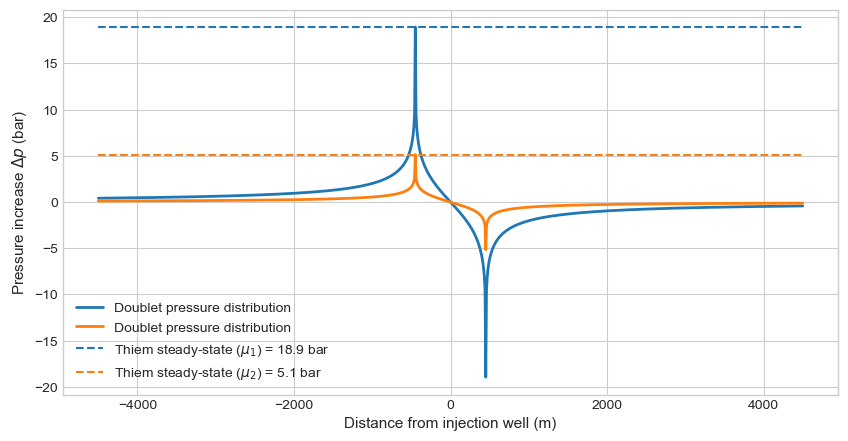

In [ ]:
from theis import doublet_pressure
faktor = 10  # Adjust this factor to scale the x-axis range as needed
nel = 50

# Create a spatial grid that considers locations in the reservoir only, because the solution is not valid inside the wells.
x1 = np.linspace(-faktor*a, -a-rw, (faktor-1)*nel)
x2 = np.linspace(-a+rw, a-rw, 2*nel)
x3 = np.linspace(a+rw, faktor*a, (faktor-1)*nel)

x = np.concatenate((x1, x2, x3))
y = np.zeros_like(x)

k_f1 = k * rho_F * g / mu1  # Convert permeability to hydraulic conductivity using mu1 (10 degC) for consistency with Theis solutions
p_doublet_mu1 = doublet_pressure(x, y, Q=-Q, M=M, k_f=k_f1, a=a, rho_F=rho_F, g=9.81, v0=0.0, alpha=0.0, p_ref=p_res)

k_f2 = k * rho_F * g / mu2  # Convert permeability to hydraulic conductivity using mu2 (20 degC) for consistency with Theis solutions
p_doublet_mu2 = doublet_pressure(x, y, Q=-Q, M=M, k_f=k_f2, a=a, rho_F=rho_F, g=9.81, v0=0.0, alpha=0.0, p_ref=p_res)

plt.figure(figsize=(10, 5))
plt.plot(x, (p_doublet_mu1 - p_res) / 1e5, color='tab:blue', linewidth=2.0, label='Doublet pressure distribution')
plt.plot(x, (p_doublet_mu2 - p_res) / 1e5, color='tab:orange', linewidth=2.0, label='Doublet pressure distribution')
plt.plot([-faktor*a, faktor*a], [dp_thiem_mu1, dp_thiem_mu1], color='tab:blue', linestyle='--', label=f'Thiem steady-state ($\\mu_1$) = {dp_thiem_mu1:.1f} bar')
plt.plot([-faktor*a, faktor*a], [dp_thiem_mu2, dp_thiem_mu2], color='tab:orange', linestyle='--', label=f'Thiem steady-state ($\\mu_2$) = {dp_thiem_mu2:.1f} bar')
plt.xlabel('Distance from injection well (m)', fontsize=11)
plt.ylabel('Pressure increase $\\Delta p$ (bar)', fontsize=11) 
plt.legend()
plt.show()   
